Christian Thede
CNN Model

Notes: 
1. Used AI for mounting and dealing with colab and google drive (and still had a ton of issues)
2. 

In [ ]:
# import ml libraries
import tensorflow as tf  # noqa: F401
import skimage  # noqa: F401
# or ------
#import sys
#!{sys.executable} -m pip install -q tensorflow scikit-image scikit-learn matplotlib

# Google Drive mount for Colab
import os
import shutil

mountpoint = "/content/drive"

from google.colab import drive
drive.mount(mountpoint, force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path

# split
TRAIN_RATIO = 0.60
TEST_RATIO = 0.30
VAL_RATIO = 0.10

# Hardcoded Colab path options (case/folder variants)
NUMS_CANDIDATES = [
    Path("/content/drive/MyDrive/Colab Notebooks/Nums"),
    Path("/content/drive/MyDrive/Colab Notebooks/nums"),
    Path("/content/drive/MyDrive/486-Final-Project/Nums"),
    Path("/content/drive/MyDrive/486-Final-Project/nums"),
]

NUMS_DIR = next((p for p in NUMS_CANDIDATES if p.exists()), NUMS_CANDIDATES[0])
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Output")

print("NUMS_DIR:", NUMS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not NUMS_DIR.exists():
    raise FileNotFoundError(
        "Could not find the dataset folder in any expected location. "
        f"Checked: {[str(p) for p in NUMS_CANDIDATES]}"
    )

# Create output folder only after we confirm Drive + dataset path are valid.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUMS_DIR: /content/drive/MyDrive/Colab Notebooks/Nums
OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/Output


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

from skimage import io, color
from skimage.transform import resize

In [4]:
# local nums
IMAGE_SIZE = (28, 28)
NUM_CLASSES = 10

# Recursive search so subfolders are also included
image_paths = sorted(list(NUMS_DIR.rglob("*.png")) + list(NUMS_DIR.rglob("*.PNG")))
print("Found", len(image_paths), "image files")

if len(image_paths) == 0:
    raise FileNotFoundError(
        f"No PNG files found in {NUMS_DIR}. "
        "Check the folder path and run Cell 1 again (and mount Drive in Colab if needed)."
    )

X_list = []
y_list = []
skipped = []

for p in image_paths:
    name = p.stem
    if not name or not name[0].isdigit():
        skipped.append(p.name)
        continue

    label = int(name[0])
    img = io.imread(str(p))

    # make grayscale
    if img.ndim == 3:
        img = color.rgb2gray(img[..., :3])

    img = resize(img, IMAGE_SIZE, anti_aliasing=True)
    X_list.append(img[..., None])
    y_list.append(label)

if len(X_list) == 0:
    preview = image_paths[:5]
    raise ValueError(
        "Found image files, but none had a leading digit label in the filename. "
        f"Examples: {[p.name for p in preview]}"
    )

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64)

print("Loaded", len(X), "usable images")
print("Skipped (no leading digit):", len(skipped))
print("X shape:", X.shape)
print("y labels:", sorted(set(y.tolist())))

# split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=TRAIN_RATIO, random_state=42, stratify=y
    )

# split into test and val
temp_test_ratio = TEST_RATIO / (TEST_RATIO + VAL_RATIO)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, train_size=temp_test_ratio, random_state=42
    )

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)
y_val_oh = keras.utils.to_categorical(y_val, NUM_CLASSES)

INPUT_CHANNELS = X_train.shape[-1]
print("Train:", X_train.shape, y_train_oh.shape)
print("Test:", X_test.shape, y_test_oh.shape)
print("Val:", X_val.shape, y_val_oh.shape)

Found 30 image files
Loaded 30 usable images
Skipped (no leading digit): 0
X shape: (30, 28, 28, 1)
y labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train: (18, 28, 28, 1) (18, 10)
Test: (8, 28, 28, 1) (8, 10)
Val: (4, 28, 28, 1) (4, 10)


In [12]:
# build model
model = keras.Sequential(
    [
        layers.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], INPUT_CHANNELS)),
        layers.Conv2D(filters=5, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=8, kernel_size=3, padding="same", activation="tanh"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(300, activation="tanh"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 5)      │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 8)      │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       117,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,328 (473.94 KB)

 Trainable params: 121,328 (473.94 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=3e-4),
loss="categorical_crossentropy",
metrics=["accuracy"],
)

callbacks = [
keras.callbacks.EarlyStopping(
monitor="val_loss", patience=20, restore_best_weights=True
),
# stop for loss?
keras.callbacks.ReduceLROnPlateau(
monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
),
]

In [14]:
# train
history = model.fit(
    X_train,
    y_train_oh,
    epochs=100,
    batch_size=8,
    validation_data=(X_val, y_val_oh),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.0556 - loss: 2.2748 - val_accuracy: 0.0000e+00 - val_loss: 2.4274 - learning_rate: 3.0000e-04
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2222 - loss: 2.1908 - val_accuracy: 0.0000e+00 - val_loss: 2.3993 - learning_rate: 3.0000e-04
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4444 - loss: 2.1283 - val_accuracy: 0.0000e+00 - val_loss: 2.3941 - learning_rate: 3.0000e-04
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6111 - loss: 2.0744 - val_accuracy: 0.0000e+00 - val_loss: 2.3902 - learning_rate: 3.0000e-04
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7222 - loss: 2.0148 - val_accuracy: 0.0000e+00 - val_loss: 2.3963 - learning_rate: 3.0000e-04
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7222 - loss: 1.9618 - val_accuracy: 0.0000e+00 - val_loss: 2.4100 - learning_rate: 3.0000e-04
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step -

In [15]:
# evaluate
train_loss, train_acc = model.evaluate(X_train, y_train_oh, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_oh, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.4f}")
print(f"Val loss:   {val_loss:.4f} | Val accuracy:   {val_acc:.4f}")
print(f"Test loss:  {test_loss:.4f} | Test accuracy:  {test_acc:.4f}")
print(f"Set sizes -> train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

# save model
model_path = OUTPUT_DIR / "digit_cnn.keras"
model.save(model_path)
print("Saved model to", model_path)

Train loss: 2.0253 | Train accuracy: 0.7222
Val loss:   2.3902 | Val accuracy:   0.0000
Test loss:  2.2608 | Test accuracy:  0.1250
Set sizes -> train: 18, val: 4, test: 8
Saved model to /content/drive/MyDrive/Colab Notebooks/Output/digit_cnn.keras


In [16]:
# predictions
probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

# sample views
for i in range(min(12, X_test.shape[0])):
    print(f"true={y_test[i]} pred={y_pred[i]} probs={np.round(probs[i], 3)}")

true=6 pred=0 probs=[0.122 0.1   0.094 0.101 0.088 0.104 0.105 0.077 0.104 0.106]
true=2 pred=2 probs=[0.108 0.111 0.131 0.075 0.084 0.102 0.073 0.099 0.098 0.118]
true=4 pred=0 probs=[0.144 0.097 0.094 0.08  0.095 0.098 0.099 0.084 0.078 0.131]
true=3 pred=2 probs=[0.086 0.104 0.13  0.093 0.092 0.113 0.085 0.102 0.106 0.089]
true=9 pred=0 probs=[0.159 0.097 0.106 0.08  0.078 0.098 0.087 0.079 0.096 0.119]
true=7 pred=2 probs=[0.113 0.1   0.13  0.084 0.095 0.111 0.083 0.087 0.091 0.106]
true=5 pred=2 probs=[0.107 0.086 0.124 0.081 0.112 0.112 0.101 0.079 0.097 0.101]
true=3 pred=5 probs=[0.099 0.103 0.114 0.1   0.088 0.123 0.083 0.097 0.097 0.095]


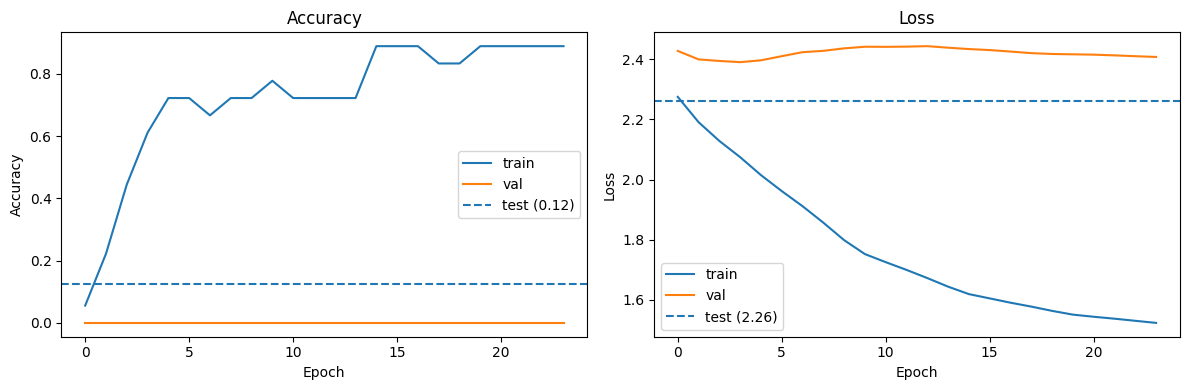

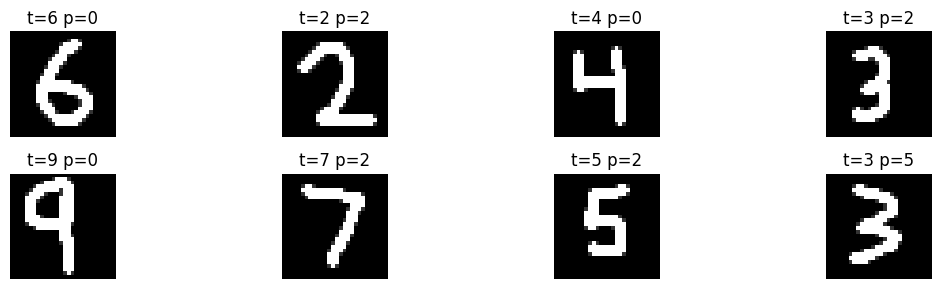

In [17]:
# visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.axhline(test_acc, linestyle="--", label=f"test ({test_acc:.2f})")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.axhline(test_loss, linestyle="--", label=f"test ({test_loss:.2f})")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# test images with predictions
n = min(12, X_test.shape[0])
plt.figure(figsize=(12, 3))
for i in range(n):
    ax = plt.subplot(2, (n + 1) // 2, i + 1)
    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"t={y_test[i]} p={y_pred[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Activation Function Search
Train several CNN variants with different activation combinations and print the best one.

In [11]:
# activation search section
from itertools import product

ACTIVATIONS = ["relu", "sigmoid", "tanh"]
EPOCHS_PER_TRIAL = 30
BATCH_SIZE_PER_TRIAL = 8

def build_activation_model(act_conv1, act_conv2, act_dense):
    return keras.Sequential(
        [
            layers.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], INPUT_CHANNELS)),
            layers.Conv2D(filters=5, kernel_size=3, padding="same", activation=act_conv1),
            layers.MaxPooling2D(pool_size=2),
            layers.Conv2D(filters=8, kernel_size=3, padding="same", activation=act_conv2),
            layers.MaxPooling2D(pool_size=2),
            layers.Flatten(),
            layers.Dense(300, activation=act_dense),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ]
    )

results = []
all_configs = list(product(ACTIVATIONS, repeat=3))
print(f"Testing {len(all_configs)} activation combinations...")

for i, (act1, act2, act3) in enumerate(all_configs, start=1):
    tf.keras.backend.clear_session()

    trial_model = build_activation_model(act1, act2, act3)
    trial_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    trial_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ]

    trial_history = trial_model.fit(
        X_train,
        y_train_oh,
        epochs=EPOCHS_PER_TRIAL,
        batch_size=BATCH_SIZE_PER_TRIAL,
        validation_data=(X_val, y_val_oh),
        callbacks=trial_callbacks,
        verbose=0,
    )

    val_loss, val_acc = trial_model.evaluate(X_val, y_val_oh, verbose=0)
    test_loss, test_acc = trial_model.evaluate(X_test, y_test_oh, verbose=0)

    result = {
        "config": (act1, act2, act3),
        "epochs_ran": len(trial_history.history["loss"]),
        "val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "val_loss": float(val_loss),
        "test_loss": float(test_loss),
    }
    results.append(result)

    print(
        f"[{i}/{len(all_configs)}] conv1={act1}, conv2={act2}, dense={act3} "
        f"| val_acc={val_acc:.4f} | test_acc={test_acc:.4f}"
    )

# Rank by validation accuracy first, then test accuracy
results_sorted = sorted(
    results,
    key=lambda r: (r["val_acc"], r["test_acc"], -r["val_loss"]),
    reverse=True,
)

best = results_sorted[0]
print("\nBest activation configuration:")
print(f"conv1={best['config'][0]}, conv2={best['config'][1]}, dense={best['config'][2]}")
print(f"val_acc={best['val_acc']:.4f}, test_acc={best['test_acc']:.4f}")
print(f"val_loss={best['val_loss']:.4f}, test_loss={best['test_loss']:.4f}")

print("\nTop 5 configurations:")
for rank, r in enumerate(results_sorted[:5], start=1):
    print(
        f"{rank}. conv1={r['config'][0]}, conv2={r['config'][1]}, dense={r['config'][2]} "
        f"| val_acc={r['val_acc']:.4f} | test_acc={r['test_acc']:.4f}"
    )

Testing 27 activation combinations...
[1/27] conv1=relu, conv2=relu, dense=relu | val_acc=0.2500 | test_acc=0.1250
[2/27] conv1=relu, conv2=relu, dense=sigmoid | val_acc=0.2500 | test_acc=0.0000
[3/27] conv1=relu, conv2=relu, dense=tanh | val_acc=0.0000 | test_acc=0.0000
[4/27] conv1=relu, conv2=sigmoid, dense=relu | val_acc=0.2500 | test_acc=0.0000
[5/27] conv1=relu, conv2=sigmoid, dense=sigmoid | val_acc=0.2500 | test_acc=0.0000
[6/27] conv1=relu, conv2=sigmoid, dense=tanh | val_acc=0.2500 | test_acc=0.0000
[7/27] conv1=relu, conv2=tanh, dense=relu | val_acc=0.0000 | test_acc=0.2500
[8/27] conv1=relu, conv2=tanh, dense=sigmoid | val_acc=0.2500 | test_acc=0.0000
[9/27] conv1=relu, conv2=tanh, dense=tanh | val_acc=0.5000 | test_acc=0.2500
[10/27] conv1=sigmoid, conv2=relu, dense=relu | val_acc=0.0000 | test_acc=0.0000
[11/27] conv1=sigmoid, conv2=relu, dense=sigmoid | val_acc=0.2500 | test_acc=0.0000
[12/27] conv1=sigmoid, conv2=relu, dense=tanh | val_acc=0.0000 | test_acc=0.1250
[13/2